In [265]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('GlobalLandTemperaturesbyCountry.csv')
df

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe
577458,2013-06-01,17.613,0.473,Zimbabwe
577459,2013-07-01,17.000,0.453,Zimbabwe
577460,2013-08-01,19.759,0.717,Zimbabwe


In [266]:
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month

#  Classify months by season (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['Month'].apply(get_season)

In [267]:
# Filter from ... (you can change this year)
df = df[df['Year'] >= 1950]
df

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month,season
2474,1950-01-01,-5.611,0.816,Åland,1950,1,Winter
2475,1950-02-01,-1.804,0.305,Åland,1950,2,Winter
2476,1950-03-01,0.090,0.439,Åland,1950,3,Spring
2477,1950-04-01,3.630,0.342,Åland,1950,4,Spring
2478,1950-05-01,8.106,0.239,Åland,1950,5,Spring
...,...,...,...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe,2013,5,Spring
577458,2013-06-01,17.613,0.473,Zimbabwe,2013,6,Summer
577459,2013-07-01,17.000,0.453,Zimbabwe,2013,7,Summer
577460,2013-08-01,19.759,0.717,Zimbabwe,2013,8,Summer


In [268]:
# List of northern hemisphere countries (if you can change ....)
northern_hemisphere = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium", "Canada", "China",
    "Denmark", "France", "Germany", "Greece", "Greenland", "Hungary", "Iceland", "India",
    "Iran", "Iraq", "Ireland", "Israel", "Italy", "Japan", "Kazakhstan",
    "Kuwait", "Lebanon", "Liechtenstein", "Luxembourg", "Mexico", "Monaco",
    "Mongolia", "Morocco", "Netherlands", "North Korea", "Norway", "Pakistan",
    "Poland", "Portugal", "Romania", "Russia", "San Marino", "Saudi Arabia",
    "Serbia", "Slovakia", "Slovenia", "South Korea", "Spain", "Sweden",
    "Switzerland", "Syria", "Svalbard and Jan Mayen", "Taiwan", "Tunisia", "Turkey", "Ukraine",
    "United Kingdom", "United States", "Vatican", "Åland"
]

# Filter northern hemisphere countries
df_north = df[df["Country"].isin(northern_hemisphere)]

# Find countries with 4 seasons
seasons_set = {"Spring", "Summer", "Autumn", "Winter"}

# Group by country and count how many unique seasons each one has
countries_with_4_seasons = (
    df_north.groupby("Country")["season"]
    .nunique()
    .reset_index()
)

# Filter those with all 4 seasons
valid_countries = countries_with_4_seasons[countries_with_4_seasons["season"] == 4]["Country"]

# Filter original DataFrame
df_final = df_north[df_north["Country"].isin(valid_countries)]

df_final
df_final = df_final.dropna()
df_final.to_csv('Average_Temperatures_season.csv', index=False)
df_final

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month,season
2474,1950-01-01,-5.611,0.816,Åland,1950,1,Winter
2475,1950-02-01,-1.804,0.305,Åland,1950,2,Winter
2476,1950-03-01,0.090,0.439,Åland,1950,3,Spring
2477,1950-04-01,3.630,0.342,Åland,1950,4,Spring
2478,1950-05-01,8.106,0.239,Åland,1950,5,Spring
...,...,...,...,...,...,...,...
557816,2013-05-01,14.073,0.178,United States,2013,5,Spring
557817,2013-06-01,20.198,0.236,United States,2013,6,Summer
557818,2013-07-01,22.074,0.152,United States,2013,7,Summer
557819,2013-08-01,21.168,0.249,United States,2013,8,Summer


In [269]:
#  Calculate average temperature per year and season and clean missing values
df_final= df.groupby(['Year', 'season'])['AverageTemperature'].mean().reset_index()
df_final = df_final.dropna()

df_final.loc[(df_final["Year"] == 2013) & (df_final["season"] == "Autumn"), "AverageTemperature"] = 20

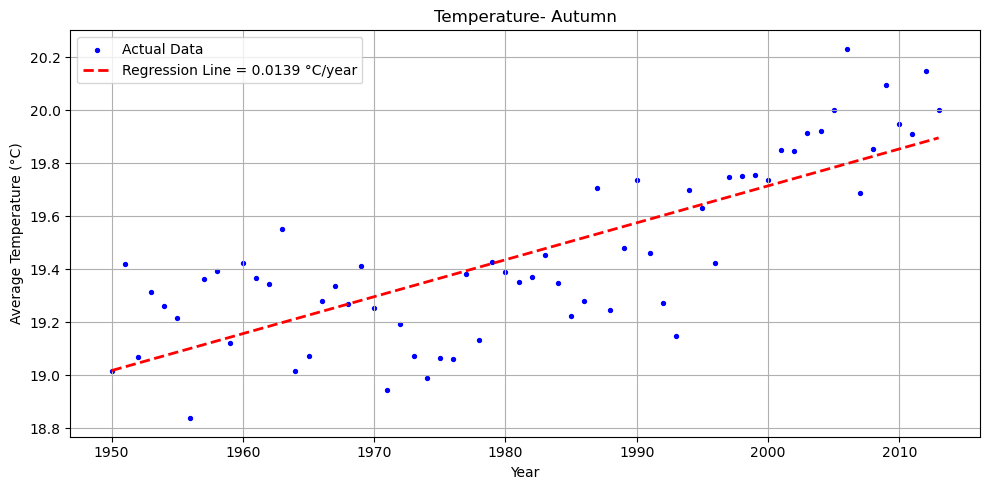

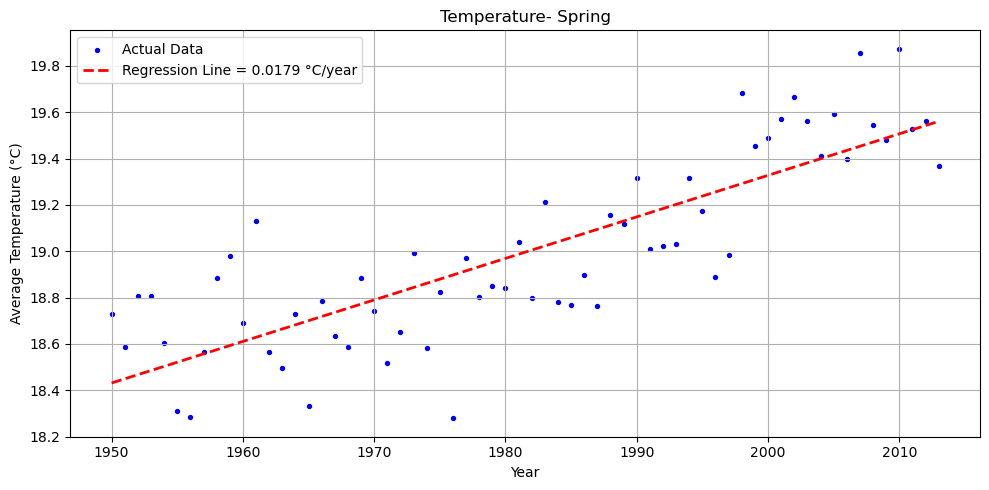

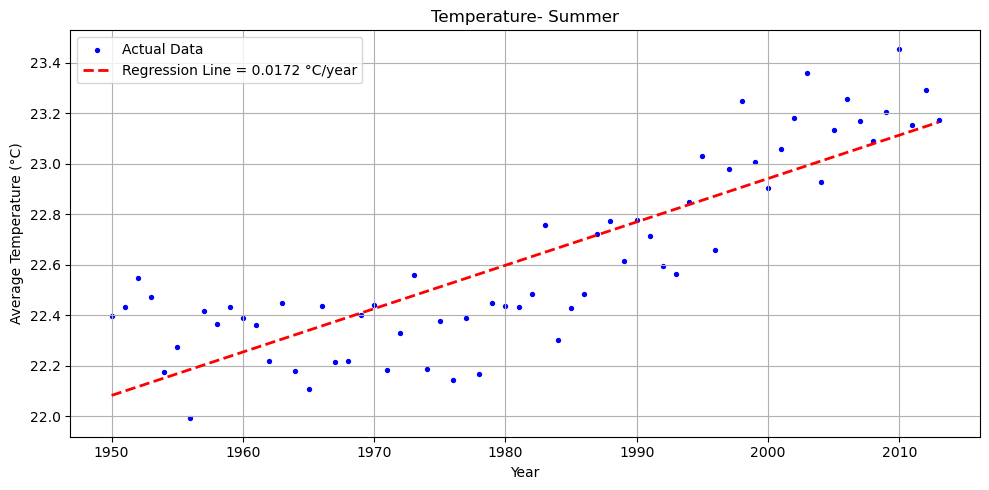

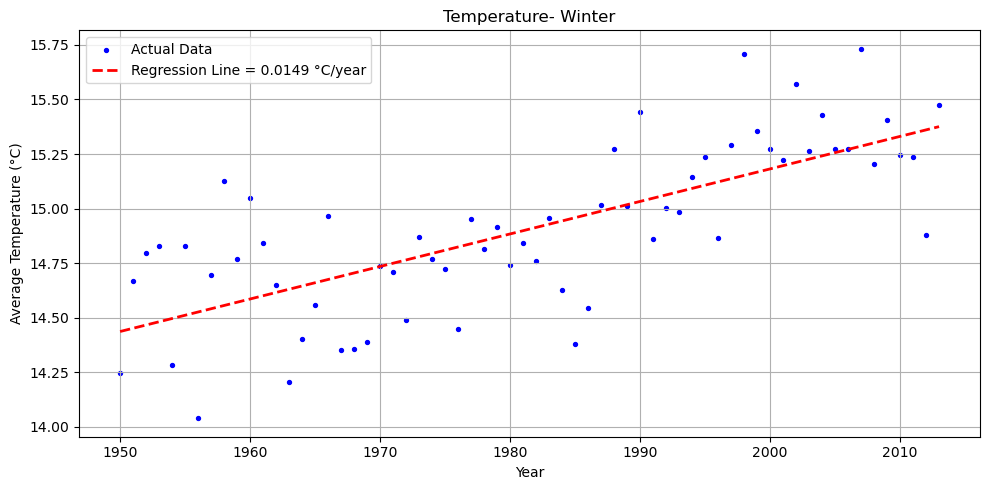

In [270]:
# Dictionary to store slope (temperature change per year) for each season
temperature_trends = {}

for season in df_final['season'].unique():
    df_season = df_final[df_final['season'] == season].dropna(subset=['Year', 'AverageTemperature'])

    X = df_season[['Year']]
    y = df_season['AverageTemperature']

    # Linear regression
    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]  # Degrees Celsius per year
    temperature_trends[season] = slope

    y_pred = model.predict(X)

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.scatter(X, y, label='Actual Data', color='blue', s=8)
    plt.plot(X, y_pred, label=f'Regression Line = {slope:.4f} °C/year', color='red', linewidth=2, linestyle = 'dashed')
    plt.title(f'Temperature- {season}')
    plt.xlabel('Year')
    plt.ylabel('Average Temperature (°C)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [271]:
df_final.to_csv('Average_Temperatures_season1.csv', index=False)